# Coupling With Land Surface Model Pyhelp


In [2]:
# -*- coding: utf-8 -*-
"""
 * Copyright (c) 2023 Alexandre Gauvain, Ronan Abhervé, Jean-Raynald de Dreuzy
 *
 * This program and the accompanying materials are made available under the
 * terms of the Eclipse Public License 2.0 which is available at
 * http://www.eclipse.org/legal/epl-2.0, or the Apache License, Version 2.0
 * which is available at https://www.apache.org/licenses/LICENSE-2.0.
 *
 * SPDX-License-Identifier: EPL-2.0 OR Apache-2.0
"""



'\n * Copyright (c) 2023 Alexandre Gauvain, Ronan Abhervé, Jean-Raynald de Dreuzy\n *\n * This program and the accompanying materials are made available under the\n * terms of the Eclipse Public License 2.0 which is available at\n * http://www.eclipse.org/legal/epl-2.0, or the Apache License, Version 2.0\n * which is available at https://www.apache.org/licenses/LICENSE-2.0.\n *\n * SPDX-License-Identifier: EPL-2.0 OR Apache-2.0\n'

In [3]:
# Libraries installed by default
import sys
import os

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import xarray as xr
import rioxarray as rxr
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

import imageio
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = False

import glob



In [4]:

"""
# Import HydroModPy modules
from os.path import dirname, abspath
# DIR = dirname(dirname(dirname(dirname(abspath(__file__)))))
DIR = 'C:/Users/rabherve/GitHub/HydroModPy-dev/'
sys.path.append(DIR)
"""

# Import HydroModPy modules
from os.path import dirname, abspath
DIR = dirname(dirname(dirname(abspath(__file__))))
sys.path.append(DIR)
sys.path.append(os.path.join(DIR, "src"))

# from os.path import dirname, abspath
# root_dir = '/home/bb/Documents/01_Git_Repository/01-HydroModPy-dev'
# sys.path.append(root_dir)



In [5]:

import hydromodpy
import importlib

# Import HydroModPy modules
from hydromodpy import watershed_root
from hydromodpy.watershed import climatic, geographic, geology, hydraulic, hydrography, hydrometry, intermittency, oceanic, piezometry, subbasin
from hydromodpy.modeling import modflow, modpath, timeseries
from hydromodpy.display import visualization_watershed, visualization_results, export_vtuvtk
from hydromodpy.tools import toolbox, folder_root

fontprop = toolbox.plot_params(8,15,18,20) # small, medium, interm, large

from hydromodpy.modeling import modflow, modpath, timeseries
from hydromodpy.pyhelp.pyhelp_netcdf import preprocessing_pyhelp



In [6]:

data_path = os.path.join(DIR, "examples", "10_coupling_with_land_surface_model_pyhelp", "data")

# The folder out_path is created in the example_path root directory:
out_path = os.path.join(DIR, "examples", "results")

print('The results of the example will be saved here :', out_path)



The results of the example will be saved here : /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results


In [7]:

# cell_size = 100
# wbt.resample(os.path.join(data_path, "ursa_RS3_rot0.tif"),
#              os.path.join(data_path, "ursa_RS3_rot0_"+str(cell_size)+".tif"),
#              cell_size)
# dem_path = os.path.join(data_path, "ursa_RS3_rot0_"+str(cell_size)+".tif")

dem_path_pyhelp = os.path.join(data_path, "ursa_RS3_rot0_250.tif")
dem_path = os.path.join(data_path, "ursa_RS3_rot0.tif")

watershed_name = "Example_10_Urse"
# watershed_name ='Strengbach'
from_lib = None # os.path.join(root_dir,'watershed_library.csv')
from_dem = None # [path, cell size]
from_shp = [os.path.join(data_path, "watershed_urse_EPSG2056.shp"), 10]
# from_xyv = [327816.965, 6777886.670, 150, 20 , 'EPSG:2154'] # [x, y, snap distance, buffer size, crs proj]
from_xyv = [2798418.619, 1133789.585, 500, 20, 'EPSG:2056']
bottom_path = None # path
save_object = True



In [ ]:

print('##### '+watershed_name.upper()+' #####')

# load = True
load = False
BV = watershed_root.Watershed(dem_path=dem_path,
                              out_path=out_path,
                              load=load,
                              watershed_name=watershed_name,
                              from_lib=from_lib, # os.path.join(root_dir,'watershed_library.csv')
                              from_dem=from_dem, # [path, cell size]
                              from_shp=from_shp, # [path, buffer size]
                              from_xyv=from_xyv, # [x, y, snap distance, buffer size]
                              bottom_path=bottom_path, # path
                              save_object=save_object)

# Paths generated automatically but necessary for plots
stable_folder = os.path.join(out_path, watershed_name, 'results_stable') # necessary for plots
simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')
calibration_folder = os.path.join(out_path, watershed_name, 'results_calibration')



[INFO]       __  __          __           __  ____          ________     
[INFO]      / / / /         / /          /  \/   /         / / __  /     
[INFO]     / /_/ /_  ______/ /________  /       /___  ____/ / /_/ /_  __ 
[INFO]    / __  / / / / __  / ___/ __ \/ /\,-/ / __ \/ __  / ____/ / / / 
[INFO]   / / / / /_/ / /_/ / /  / /_/ / /   / / /_/ / /_/ / /   / /_/ /  
[INFO]  /_/ /_/\__, /_____/_/   \____/_/   /_/\____/_____/_/____\__, /   
[INFO]        /____/ Hydrological Modelling in Python /_____________/    
[INFO]                                                                   
[INFO] Initializing watershed object from scratch as requested
[INFO] Extracting geographic data for model area


##### EXAMPLE_10_URSE #####


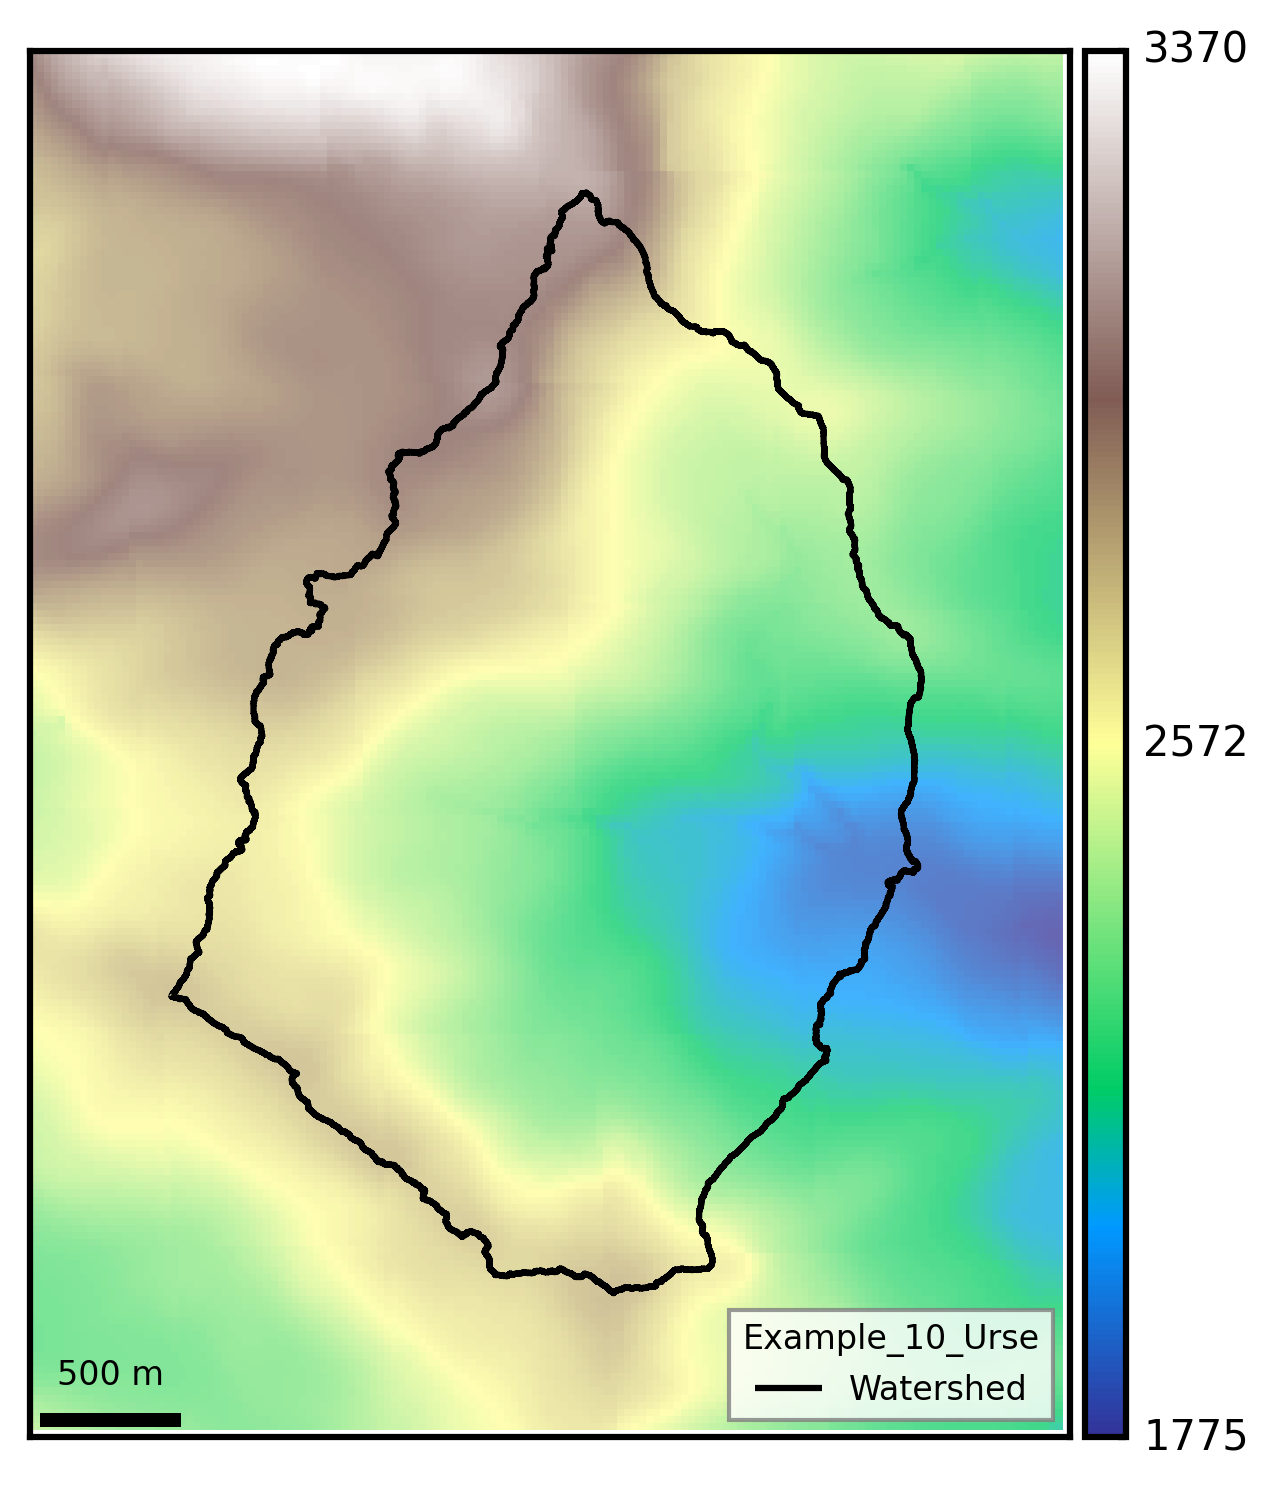

In [ ]:

KB4_loc = [2796960.102,1133328.361] #???
visualization_watershed.watershed_dem(BV)



In [ ]:

pyhelp_workdir = os.path.join(out_path, watershed_name, "results_pyhelp")
era5_folder = os.path.join(data_path)

### If already completed grid:
grid_base_csv = data_path+"/"+"_init_input_grid_base1/"+"input_grid_base1.csv"

ready_csvs = [
    os.path.join(era5_folder, "precip_input_data.csv"),
    os.path.join(era5_folder, "airtemp_input_data.csv"),
    os.path.join(era5_folder, "solrad_input_data.csv")
]



In [ ]:

k_values = [4.28e-8 * 3600 * 24] #◘ 0.0037 m/day

list_of_sims = []

option = '1'

for k in k_values[:]:

    k = round(k, 5)

    grid_kwargs = dict(
                       growth_start=140,
                       growth_end=280,
                       wind=2.5,
                       hum1=60, hum2=65, hum3=70, hum4=70,
                       LAI=2.4,
                       EZD=44.5,
                       CN=55,
                       nlayer=1,
                       lay_type1=1,
                       thick1=100,
                       poro1=0.45,
                       fc1=0.23,
                       wp1=0.116,
                       ksat1=k,
                       dist_dr1=50,
                       slope1=35
                       )

    # cid                             Unique cell ID
    # lat_dd                          Decimal degrees Latitude of the cell centroid
    # lon_dd                          Decimal degrees Longitude of the cell centroid

    # wind            km/h            Average annual wind speed
    # hum1            %               Average quarterly relative humidity (Jan to Mar)
    # hum2            %               Average quarterly relative humidity (Apr to Jun)
    # hum3            %               Average quarterly relative humidity (Jul to Sep)
    # hum4            %               Average quarterly relative humidity (Oct to Dec)
    # growth_start    julian day      First day of the growing season
    # growth_end      julian day      Last day of the growing season
    # LAI             –               Maximum leaf area index
    # EZD             cm              Evaporative zone depth
    # CN              –               Curve Number
    # nlayer          –               Number of hydrostratigraphic layers at cell cid
    # lay_type{i}     –               Type of HELP layer of the ith soil layer
    # thick{i}        cm              Thickness of the ith soil layer
    # poro{i}         m3/m3           Total porosity of the ith soil layer
    # fc{i}           m3/m3           Field capacity of the ith soil layer
    # wp{i}           m3/m3           Wilting point of the ith soil layer
    # ksat            cm/s            Saturated hydraulic conductivity of the ith soil layer
    # dist_dr         m               Distance to discharge
    # slope           %               Average slope

    # run             –               Identify cells to be run with the HELP model
    # context         –               Identify cells by context:
    #     0 - Water cell
    #     1 - Normal cell
    #     2 - Stream edge with superficial hypodermic runoff
    #     3 - River edge with deep hypodermic runoff
    #     4 - Urban cell
    #     5 - Cell not mapped

    if option == '1':

        #---- Input climatic ready - Input grid updated:
        nc = preprocessing_pyhelp(
            workdir = os.path.join(pyhelp_workdir, f"_sim_{k}"),
            outpath = os.path.join(pyhelp_workdir, f"_sim_{k}"),
            ready_csvs = ready_csvs,
            grid_kwargs = grid_kwargs,
            dem = dem_path_pyhelp,
            shapefile = from_shp[0],
        )
        # print("NetCDF :", nc)

    if option == '2':

        #---- Input climatic ready - Input grid ready:

        nc = preprocessing_pyhelp(
            workdir = pyhelp_workdir,
            outpath = simulations_folder,
            grid_csv = grid_base_csv,
            ready_csvs = ready_csvs,
        )
        # print("NetCDF :", nc)

    """
    if option == '3':

        #---- Input climatic updated - Input grid updated:
        nc = preprocessing_pyhelp(
            workdir = pyhelp_workdir,
            outpath = simulations_folder,
            dem = dem_path_pyhelp,
            era5_folder = era5_folder,
            grid_kwargs = grid_kwargs,
            conda_env   = "pyhelp_env",
        )
        # print("NetCDF :", nc)
    """

    list_of_sims.append(f"_sim_{k}")



[INFO] Updating PyHELP grid geometry before run
[INFO] Updated grid saved to /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_10_Urse/results_pyhelp/_sim_0.0037/input_grid_base1.csv
[INFO] Executing pyHELP CLI workflow
[INFO] Launching help_example.py workflow: /home/bb/miniforge3/envs/testpip313/bin/python /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/hydromodpy/pyhelp/help_example.py --workdir /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_10_Urse/results_pyhelp/_sim_0.0037
[INFO] pyhelp.bilan module resolved at /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/hydromodpy/pyhelp/bilan.py
[INFO] Loading grid data from /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_10_Urse/results_pyhelp/_sim_0.0037/input_grid_base1.csv
[INFO] Grid data loaded successfully from /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_10_Urse/results_pyhelp/_sim_0.0037/in

In [12]:

name_sim = list_of_sims[0]

csv_path = pyhelp_workdir + '/' + name_sim + "/help_example_daily_mean.csv"

df = pd.read_csv(csv_path)
df = df.rename(columns={df.columns[0]: "time"})
formatted_csv_path =  pyhelp_workdir + '/' + name_sim + "/help_example_daily_mean_formatted.csv"
df.to_csv(formatted_csv_path, index=False)



In [ ]:

nc_path  = pyhelp_workdir + '/' + name_sim + "/_pyhelp_outputs_grid.nc"
dem_path = stable_folder + "/geographic/watershed_box_buff_dem.tif"

ds  = xr.open_dataset(nc_path)
dem = rxr.open_rasterio(dem_path)

R = ds["rechg"]
R = R.rio.write_crs(dem.rio.crs)

Rt   = R.rio.reproject_match(dem, nodata=0.0)
cube = Rt.values / 1000

recharge_dict = {i: cube[i] for i in range(cube.shape[0])}



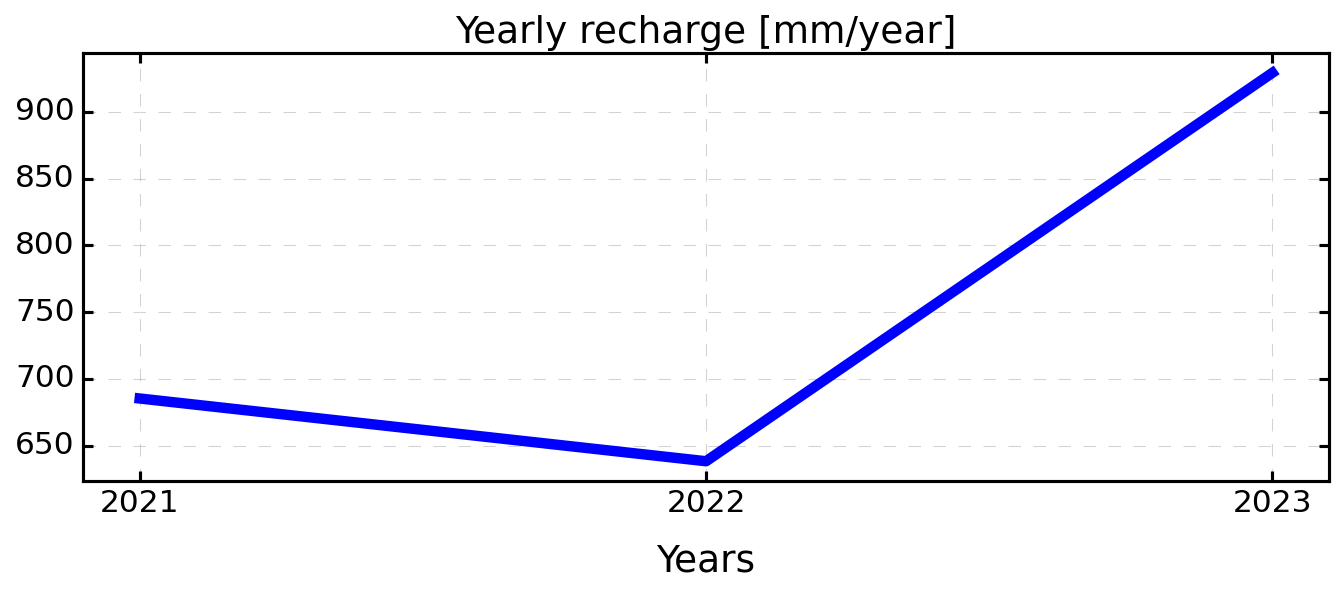

In [14]:

rec_path = pyhelp_workdir + '/' + name_sim + "/help_example_daily_mean_formatted.csv"

rec_data = pd.read_csv(rec_path, sep=',')
rec_data = rec_data[['time','rechg']]
rec_mean = rec_data.groupby('time', as_index=False).mean()
rec_mean['time'] = pd.to_datetime(rec_mean['time'])
rec_mean = rec_mean.set_index(['time'])
# rec_mean[rec_mean==0] = np.nan
years = rec_mean.index.year.unique()

# Calculer la moyenne annuelle
rec_annual = rec_mean.resample('Y').sum()

# Extraire les années pour l'axe X
years = rec_annual.index.year
rec_annual.index = years  # Remplacer l'index par les années pures

# Tracé
plt.figure(figsize=(9, 4), dpi=150)

plt.plot(rec_annual.index, rec_annual['rechg'], color='blue', lw=5)

plt.xlabel('Years')
# plt.yscale('log')  # Optionnel selon échelle
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.title('Yearly recharge [mm/year]')

# Mettre les années en xticks proprement
plt.xticks(ticks=years, labels=[str(y) for y in years])

plt.tight_layout()
plt.show()



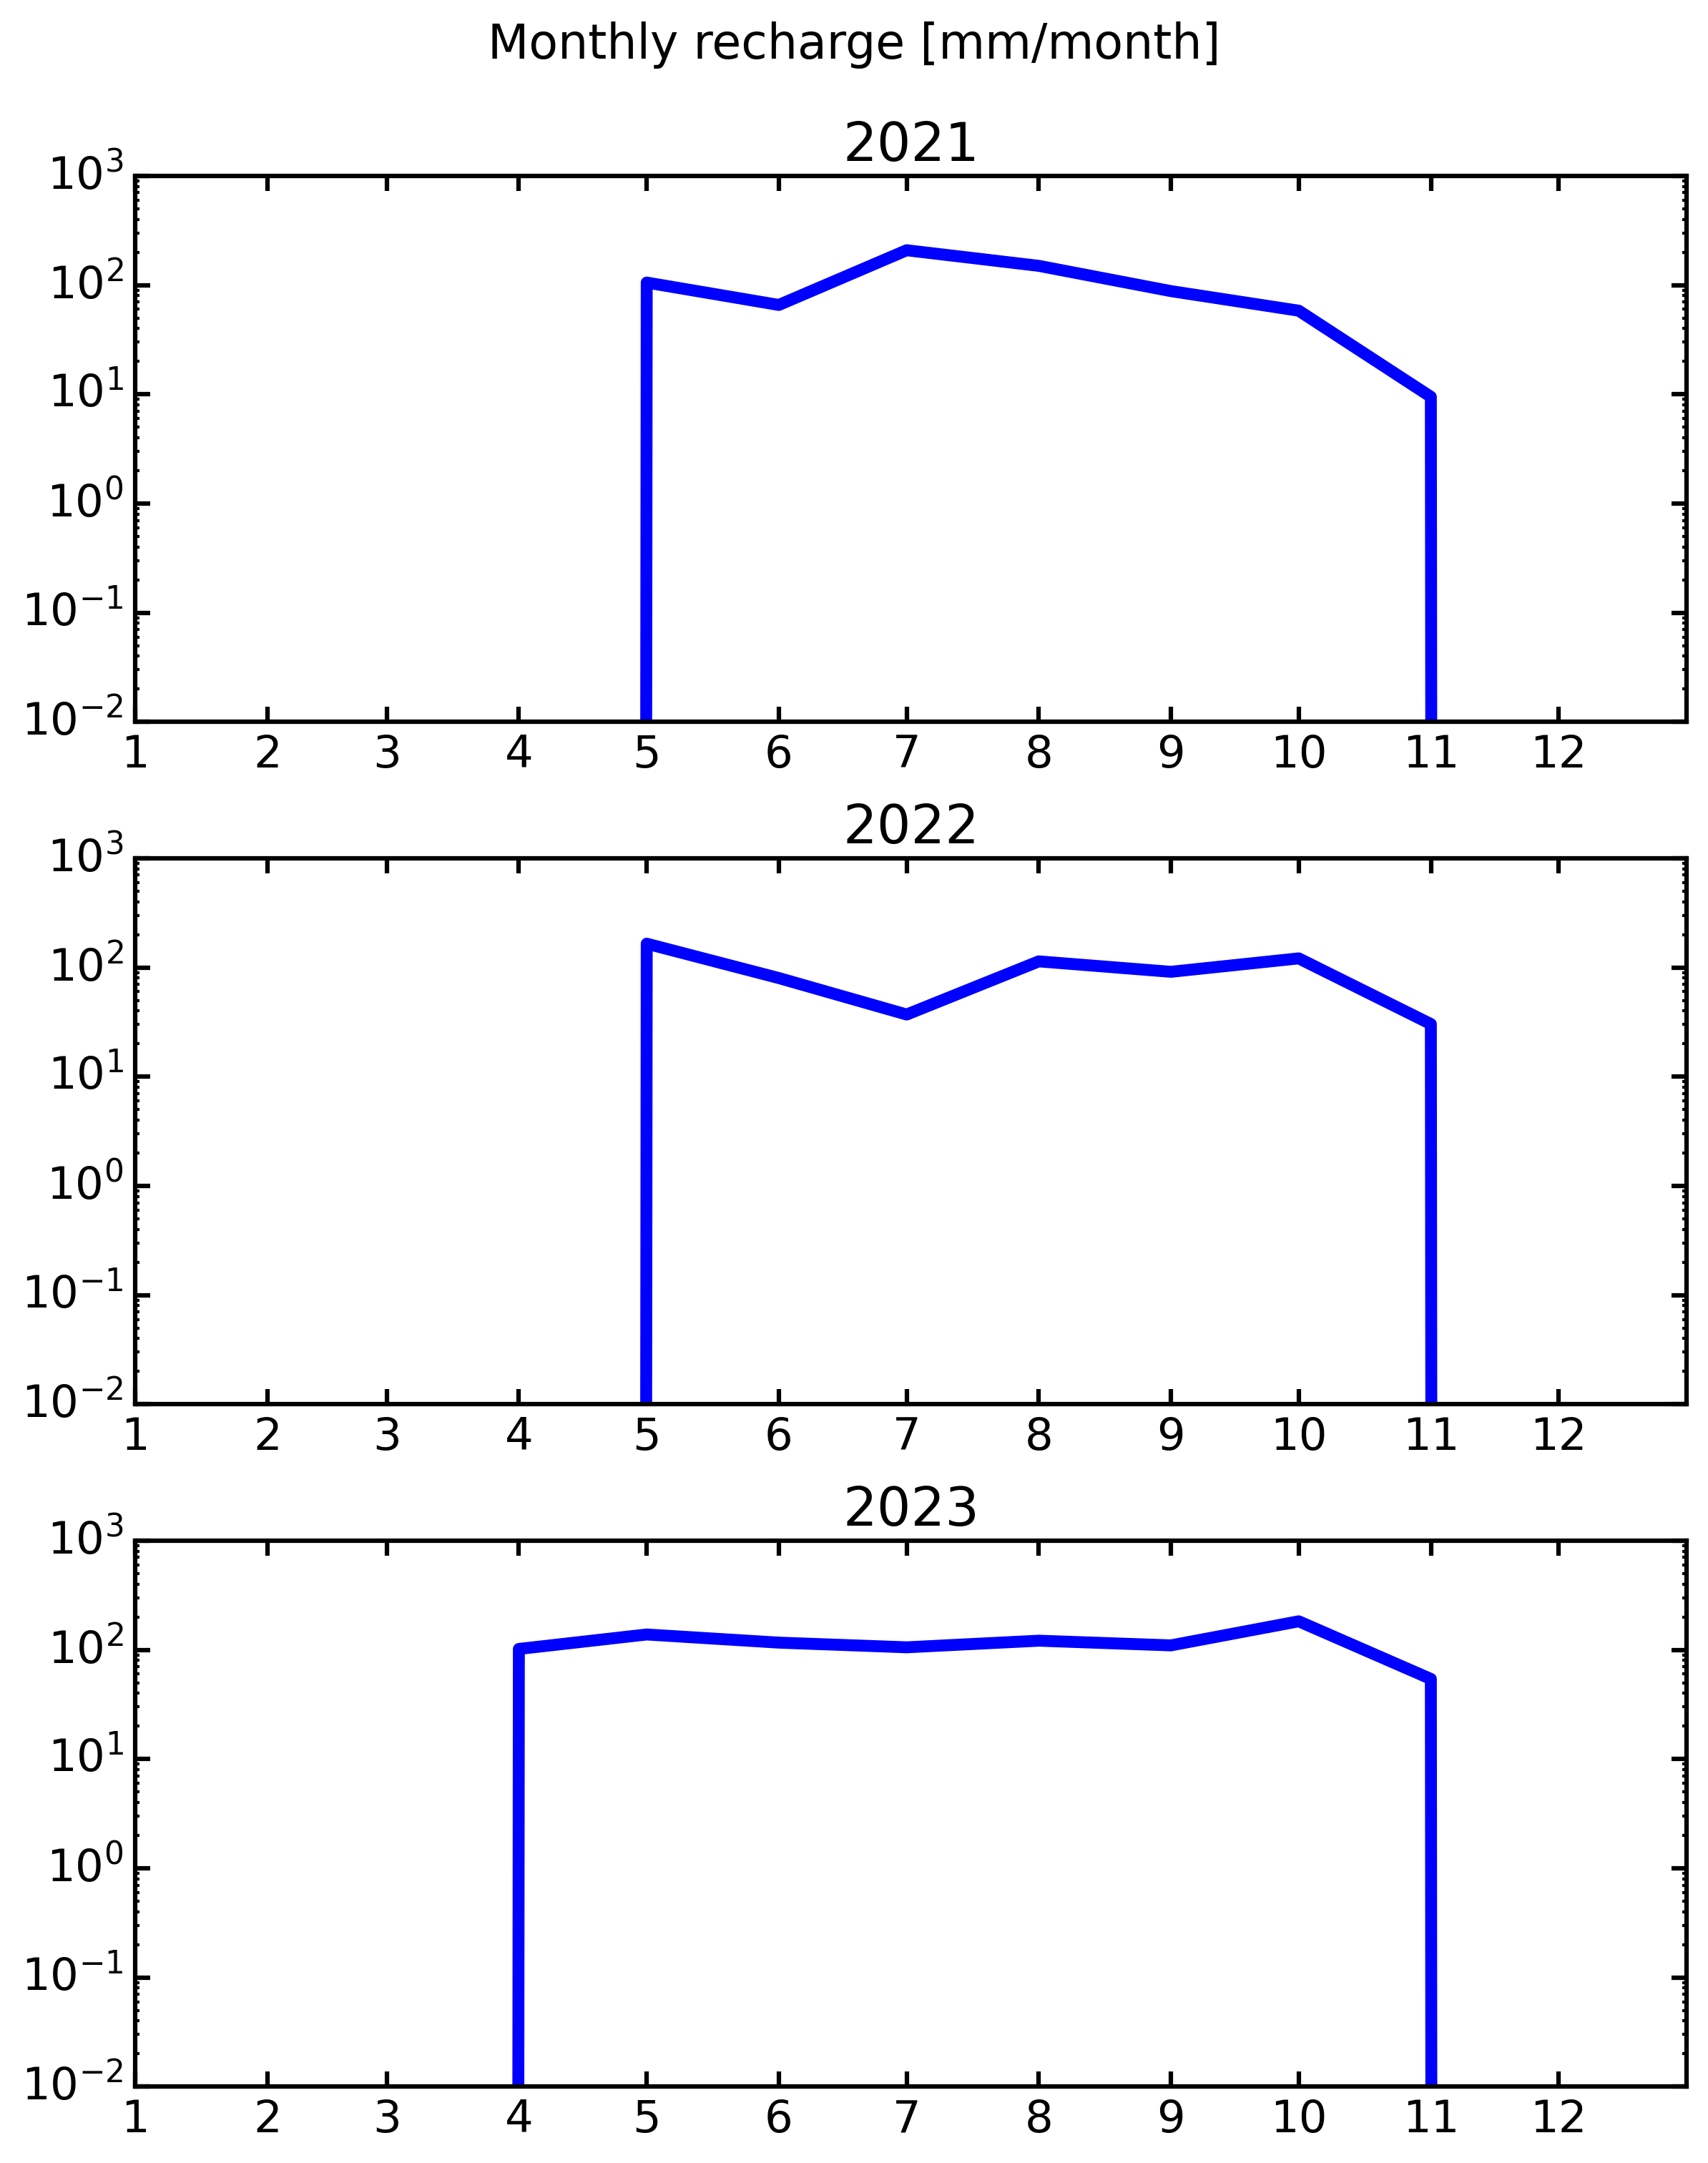

In [ ]:

rec_data = pd.read_csv(rec_path, sep=',')
rec_data = rec_data[['time','rechg']]
rec_mean = rec_data.groupby('time', as_index=False).mean()
rec_mean['time'] = pd.to_datetime(rec_mean['time'])
# rec_mean = rec_mean.set_index(['time'])
# rec_mean[rec_mean==0] = np.nan
years = rec_mean['time'].dt.year.unique()

# Ajouter colonnes année et mois
rec_mean['year'] = rec_mean['time'].dt.year
rec_mean['month'] = rec_mean['time'].dt.month

# Sélectionner uniquement les colonnes numériques à sommer
cols_to_sum = ['rechg']

# Grouper par année et mois, et sommer
rec_monthly = rec_mean.groupby(['year', 'month'], as_index=False)[cols_to_sum].sum()

# Créer une colonne datetime pour l'axe x (1er jour de chaque mois)
rec_monthly['time'] = pd.to_datetime(dict(year=rec_monthly['year'], month=rec_monthly['month'], day=1))

# Mettre en index temporel
rec_monthly = rec_monthly.set_index('time')

# Liste des années
years = rec_monthly['year'].unique()

# Tracé
fig, axs = plt.subplots(3, 1, figsize=(8, 10), dpi=300, sharey=True)
axs = axs.ravel()

for i, y in enumerate(years[:]):  # Saute la première année si besoin
    ax = axs[i]
    data_y = rec_monthly[rec_monthly['year'] == y]

    ax.plot(data_y.index, data_y['rechg'], color='blue', lw=4, zorder=2)

    ax.set_yscale('log')
    ax.set_xlim(pd.to_datetime(f'{y}-01-01'), pd.to_datetime(f'{y}-12-31'))
    ax.set_ylim(1e-2, 1e3)
    ax.set_title(str(y))

    month_ticks = pd.date_range(start=f'{y}-01-01', end=f'{y}-12-31', freq='MS')
    ax.set_xticks(month_ticks)
    ax.set_xticklabels([str(m.month) for m in month_ticks])

    if i == 0:
        ax.legend(loc='upper left', frameon=False, fontsize=13)

plt.suptitle('Monthly recharge [mm/month]', fontsize=16, y=1)
plt.tight_layout()



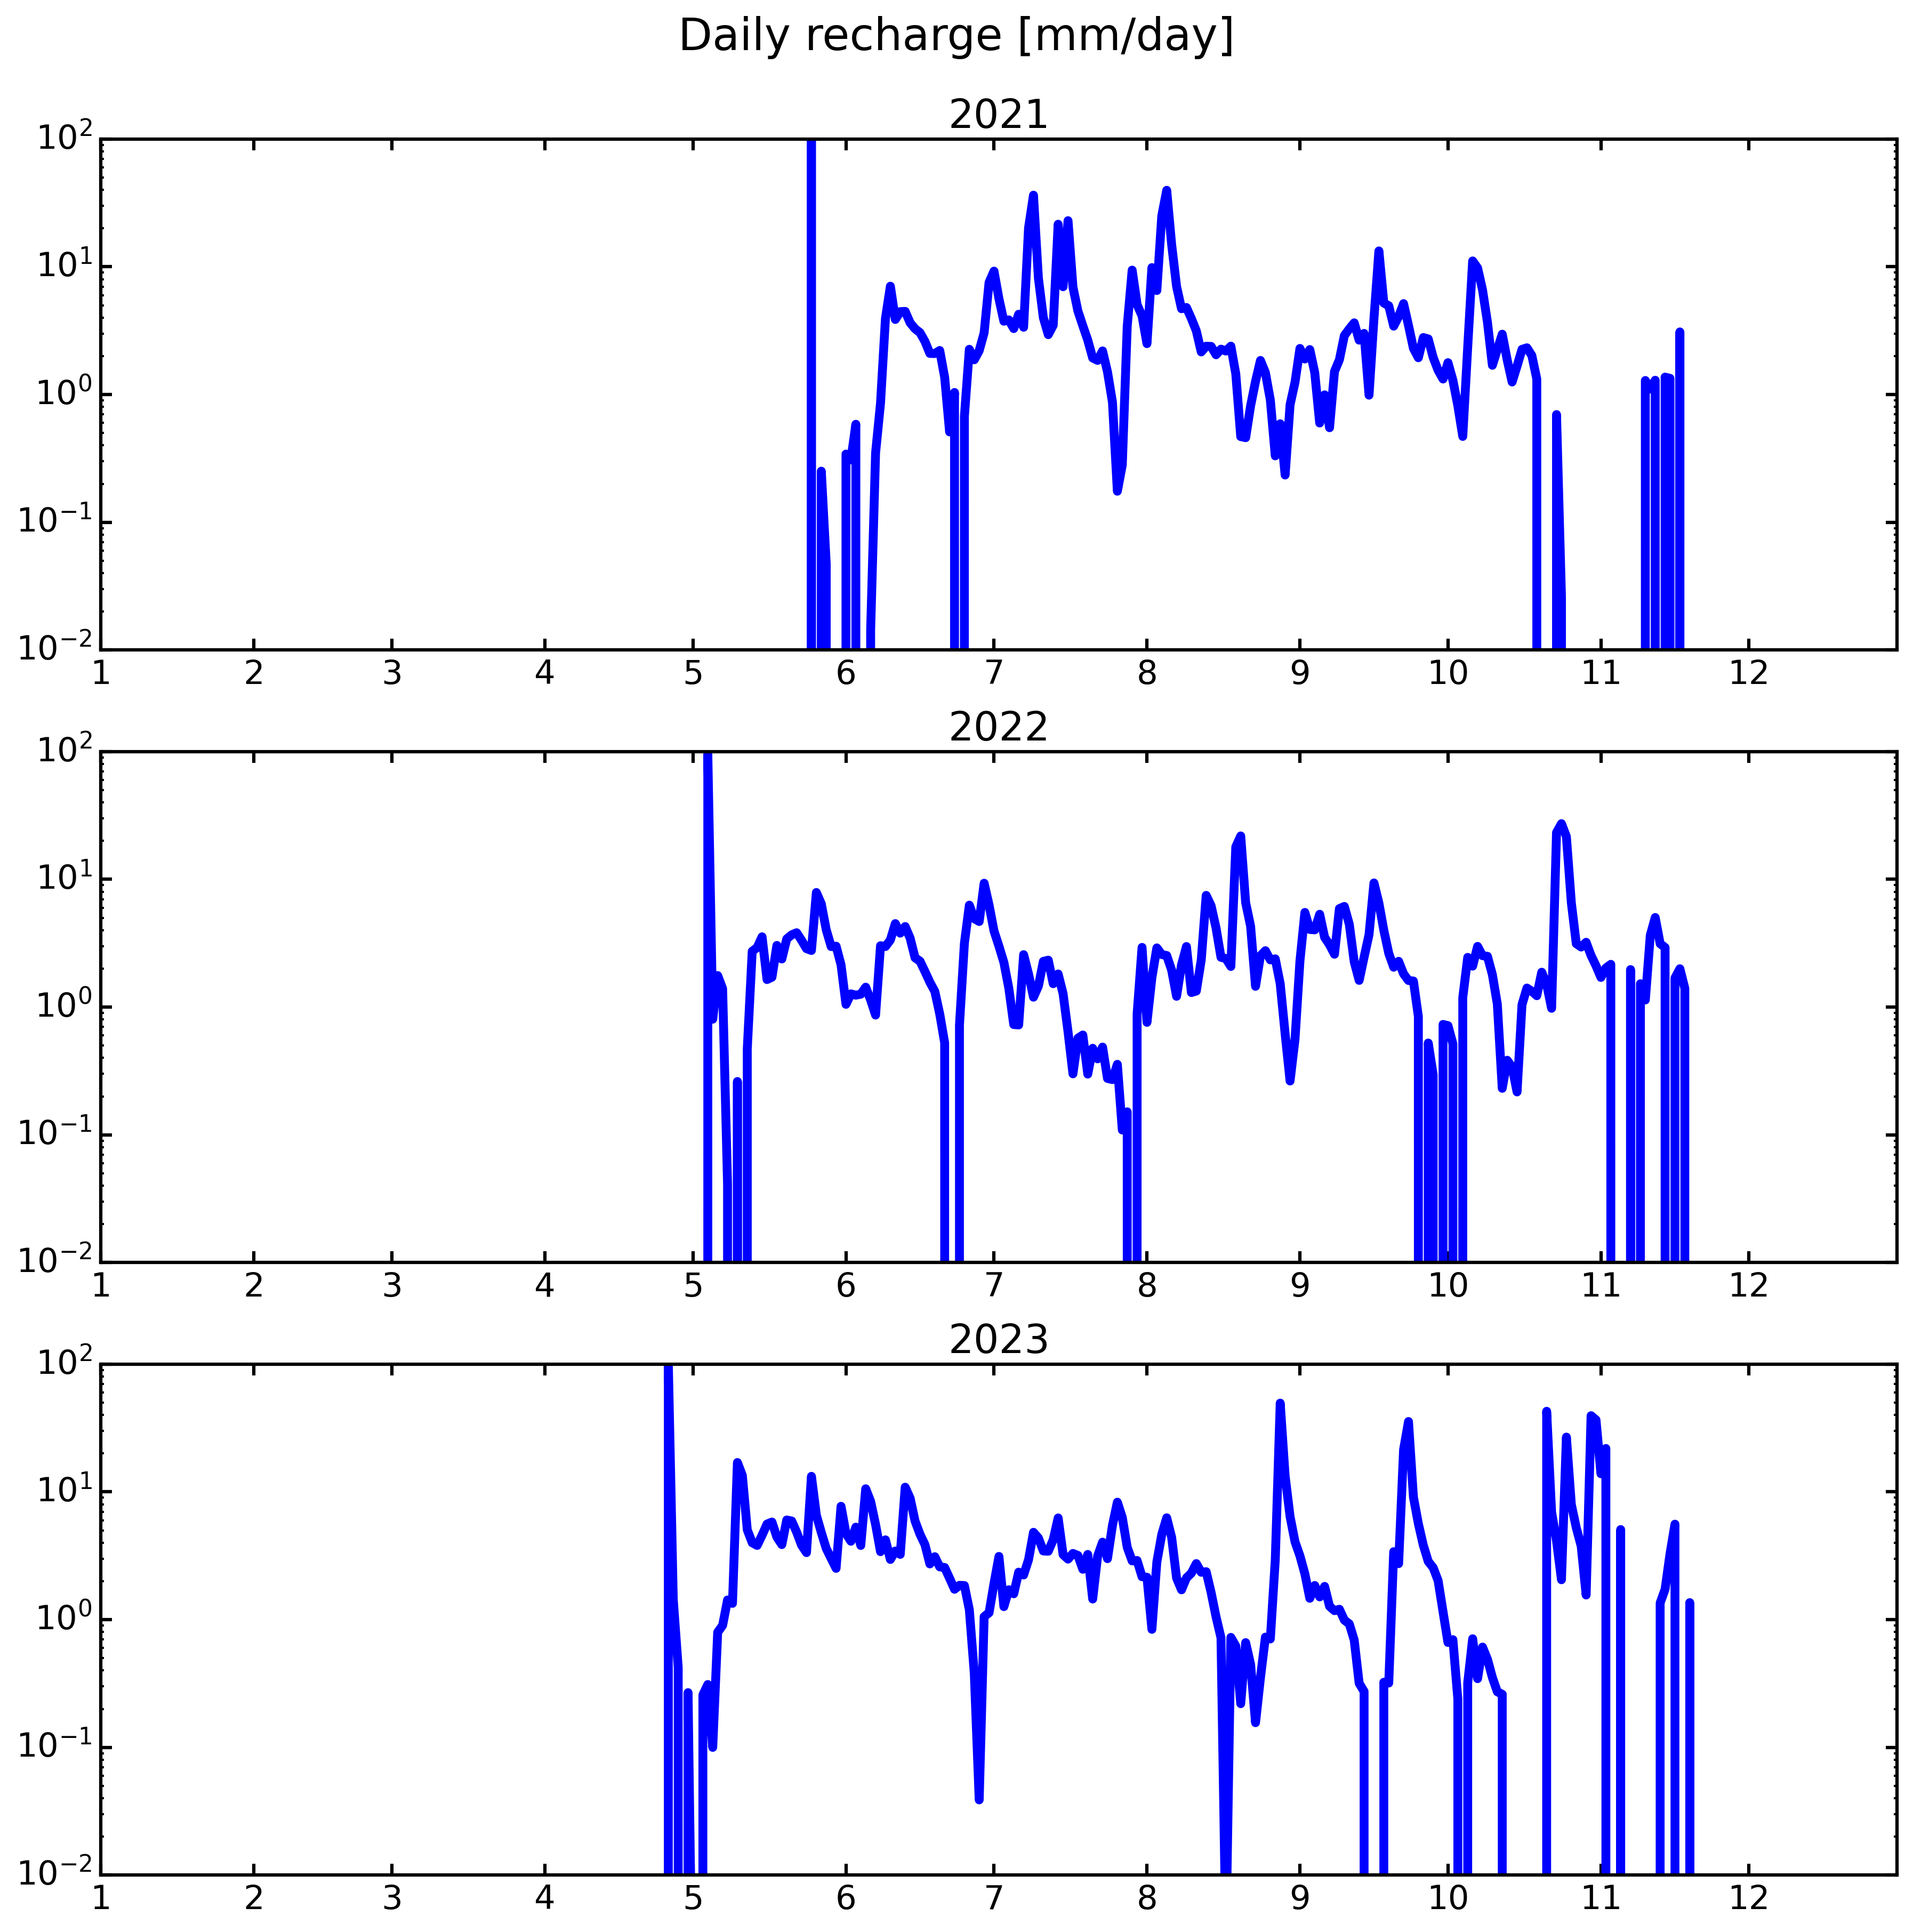

In [16]:

rec_data = pd.read_csv(rec_path, sep=',')
rec_data = rec_data[['time','rechg']]
rec_mean = rec_data.groupby('time', as_index=False).mean()
rec_mean['time'] = pd.to_datetime(rec_mean['time'])
rec_mean = rec_mean.set_index(['time'])
years = rec_mean.index.year.unique()

fig, axs = plt.subplots(3, 1, figsize=(12, 12), dpi=300, sharey=True)
axs = axs.ravel()

for i, y in enumerate(years[:]):
    ax = axs[i]
    ax.plot(rec_mean['rechg'], color='b', lw=4, zorder=2, label='Ref')
    ax.set_yscale('log')
    ax.set_xlim(pd.to_datetime(f'{y}-01-01'), pd.to_datetime(f'{y}-12-31'))
    ax.set_ylim(1e-2,100)
    ax.set_title(str(y))
    month_ticks = pd.date_range(start=f'{y}-01-01', end=f'{y}-12-31', freq='MS')
    ax.set_xticks(month_ticks)
    ax.set_xticklabels([str(m.month) for m in month_ticks])

plt.suptitle('Daily recharge [mm/day]', y=1)
plt.tight_layout()



In [ ]:

class MatchingStreams:
    """

    Class for the calibration based on river occurency

    Attributes
    ----------

    Methods
    ----------

    """

    def __init__(self,
                 watershed,
                 iteration_label=None,
                 from_calib=True):

        self.geographic = watershed.geographic
        self.hydrography = watershed.hydrography
        if from_calib==True:
            self.calibration_folder = watershed.calibration_folder
        else:
            self.calibration_folder = watershed.simulations_folder
        self.iteration_label = iteration_label

        self.watershed_shp = watershed.geographic.watershed_shp
        self.watershed_fill = watershed.geographic.watershed_fill
        self.watershed_direc = watershed.geographic.watershed_direc

        self.prepare_files()
        self.sim_to_obs()
        self.obs_to_sim()
        # self.get_indicator()

    def prepare_files(self):
        #files are necessary for whiteboxtool
        self.results_folder=os.path.join(self.calibration_folder, self.iteration_label, '_postprocess')
        toolbox.create_folder(self.results_folder)
        # New folder results
        self.dichotomy_folder = os.path.join(self.calibration_folder, self.iteration_label, '_matchingstreams')
        toolbox.create_folder(self.dichotomy_folder)

        # Observed buff data
        self.buff_tif_obs = self.hydrography.tif_streams
        # Mask observed
        self.tif_obs = os.path.join(self.dichotomy_folder,'obs.tif')
        toolbox.clip_tif(self.buff_tif_obs, self.watershed_shp, self.tif_obs, False)
        # Obs to points
        self.pt_obs = os.path.join(self.dichotomy_folder, 'obs_pt.shp')
        wbt.raster_to_vector_points(self.tif_obs, self.pt_obs)
        self.pt_obsf = os.path.join(self.dichotomy_folder, 'obs_ptf.shp')
        wbt.raster_to_vector_points(self.tif_obs, self.pt_obsf)
        # Trace downslope obs
        self.obs_flow = os.path.join(self.dichotomy_folder, 'obsflow.tif')
        wbt.trace_downslope_flowpaths(self.pt_obs, self.watershed_direc, self.obs_flow)

        # Mask simulated
        tif_sim = os.path.join(self.results_folder,'_rasters','seepage_areas_t(0).tif')
        self.tif_sim = os.path.join(self.dichotomy_folder,'sim.tif')
        toolbox.clip_tif(tif_sim, self.watershed_shp, self.tif_sim, False)
        # Sim to points
        self.pt_sim = os.path.join(self.dichotomy_folder, 'sim_pt.shp')
        wbt.raster_to_vector_points(self.tif_sim, self.pt_sim)
        self.pt_simf = os.path.join(self.dichotomy_folder, 'sim_ptf.shp')
        wbt.raster_to_vector_points(self.tif_sim, self.pt_simf)
        # Trace downslope sim
        self.sim_flow = os.path.join(self.dichotomy_folder, 'simflow.tif')
        wbt.trace_downslope_flowpaths(self.pt_sim, self.watershed_direc, self.sim_flow)

    def sim_to_obs(self):
        # Simflow to points
        self.pt_sim_flow = os.path.join(self.dichotomy_folder, 'simflow.shp')
        wbt.raster_to_vector_points(self.sim_flow, self.pt_sim_flow)
        self.pt_sim_flowf = os.path.join(self.dichotomy_folder, 'simflowf.shp')
        wbt.raster_to_vector_points(self.sim_flow, self.pt_sim_flowf)

        # Distance of dem to obs
        self.dist_dem_obs = os.path.join(self.dichotomy_folder, 'dist_dem_obs.tif')
        wbt.downslope_distance_to_stream(self.watershed_fill, self.tif_obs, self.dist_dem_obs)

        # Distance of dem to obsflow
        self.dist_dem_obsflow = os.path.join(self.dichotomy_folder, 'dist_dem_obsflow.tif')
        wbt.downslope_distance_to_stream(self.watershed_fill, self.obs_flow, self.dist_dem_obsflow)

        # Sim to Obs and Obsflow
        wbt.add_point_coordinates_to_table(self.pt_sim)
        wbt.extract_raster_values_at_points(self.dist_dem_obs, self.pt_sim)
        wbt.add_point_coordinates_to_table(self.pt_simf)
        wbt.extract_raster_values_at_points(self.dist_dem_obsflow, self.pt_simf)
        # Simflow to Obs and Obsflow
        wbt.add_point_coordinates_to_table(self.pt_sim_flow)
        wbt.extract_raster_values_at_points(self.dist_dem_obs, self.pt_sim_flow)
        wbt.add_point_coordinates_to_table(self.pt_sim_flowf)
        wbt.extract_raster_values_at_points(self.dist_dem_obsflow, self.pt_sim_flowf)

    def obs_to_sim(self):
        # Simflow to points
        self.pt_obs_flow = os.path.join(self.dichotomy_folder, 'obsflow.shp')
        wbt.raster_to_vector_points(self.obs_flow, self.pt_obs_flow)
        self.pt_obs_flowf = os.path.join(self.dichotomy_folder, 'obsflowf.shp')
        wbt.raster_to_vector_points(self.obs_flow, self.pt_obs_flowf)

        # Distance of dem to sim
        self.dist_dem_sim = os.path.join(self.dichotomy_folder, 'dist_dem_sim.tif')
        wbt.downslope_distance_to_stream(self.watershed_fill, self.tif_sim, self.dist_dem_sim)
        # Distance of dem to simflow
        self.dist_dem_simflow = os.path.join(self.dichotomy_folder, 'dist_dem_simflow.tif')
        wbt.downslope_distance_to_stream(self.watershed_fill, self.sim_flow, self.dist_dem_simflow)

        # Obs to Sim and Simflow
        wbt.add_point_coordinates_to_table(self.pt_obs)
        wbt.extract_raster_values_at_points(self.dist_dem_sim, self.pt_obs)
        wbt.add_point_coordinates_to_table(self.pt_obsf)
        wbt.extract_raster_values_at_points(self.dist_dem_simflow, self.pt_obsf)
        # Obsflow to Sim and Simflow
        wbt.add_point_coordinates_to_table(self.pt_obs_flow)
        wbt.extract_raster_values_at_points(self.dist_dem_sim, self.pt_obs_flow)
        wbt.add_point_coordinates_to_table(self.pt_obs_flowf)
        wbt.extract_raster_values_at_points(self.dist_dem_simflow, self.pt_obs_flowf)



In [ ]:

vers = 'DICHOT2' # dichotomy on 30 catchments (all hydrosystems)

box = False # or False
sink_fill = False # or True
sim_state = 'steady' # 'steady' or 'transient'
plot_cross = False
dis_perlen = True
nlay = 1
lay_decay = 1 # 1 for no decay
first_clim = 'mean' # or 'first or value
verti_hk = None # or [ [1e-5, [0, 20]],
verti_sy = None
verti_ss = None
cond_drain = None # or value of conductance
Kmin = 1e-10 * 3600 * 24
Klog_transf = False
sy = 1 / 100 # -
sy_decay = 0 # exponential decay : 1/20 (half decrease at 20m)
hk_decay = 0
ss = 1e-5
ss_decay = 0 # exponential decay : 1/20 (half decrease at 20m)
bc_left = None # or value
bc_right = None # or value
sea_level = 'None' # or value based on specific data : BV.oceanic.MSL
zone_partic = 'domain' # or watershed
vka = 1
bottom = None
thickness = 50

rec_data = pd.read_csv(rec_path, sep=',')
rec_data = rec_data[['time','rechg']]
rec_mean = rec_data.groupby('time', as_index=False).mean()
rec_mean['time'] = pd.to_datetime(rec_mean['time'])
rec_mean = rec_mean.set_index(['time'])

recharge_csv = rec_mean['rechg']

print(f"Recharge: {recharge_csv.mean()*365} mm/y")



Recharge: 750.909317 mm/y


In [ ]:

BV = watershed_root.Watershed(watershed_name=watershed_name, dem_path=None, out_path=out_path, load=True)
area = BV.geographic.area

path_dem = BV.geographic.watershed_dem
dem = imageio.imread(path_dem)
dem = np.ma.masked_array(dem, mask=dem<0)
dem_cells = dem.count()

path_buff = BV.geographic.watershed_buff_dem
buff = imageio.imread(path_buff)
buff = np.ma.masked_array(buff, mask=buff<0)
buff_cells = buff.count()

path_box = BV.geographic.watershed_box_buff_dem
boxc = imageio.imread(path_box)
boxc = np.ma.masked_array(boxc, mask=boxc<0)
boxc_cells = boxc.count()

# Create folders
stable_folder = out_path+'/'+watershed_name+'/'+'results_stable/' # necessary for plots
simulations_folder = out_path+'/'+watershed_name+'/'+'results_simulations/' # necessary for plots
toolbox.create_folder(simulations_folder)
BV.calibration_folder = os.path.join(out_path, watershed_name, 'results_calibration')
toolbox.create_folder(BV.calibration_folder)
calibration_folder = os.path.join(out_path, watershed_name, 'results_calibration')

# Type obs hydro
BV.add_hydrography(data_path, types_obs=['stream_network_urse_reproj'])

# Objects
BV.add_settings()
BV.add_climatic()
BV.add_hydraulic()
BV.add_oceanic(sea_level)

# Updated
BV.settings.update_box_model(box)
BV.settings.update_sink_fill(sink_fill)
BV.settings.update_simulation_state(sim_state)
BV.climatic.update_first_clim(first_clim)
BV.hydraulic.update_nlay(nlay) # 1
BV.hydraulic.update_lay_decay(lay_decay) # 1
BV.hydraulic.update_cond_drain(cond_drain)
BV.hydraulic.update_sy(sy)
BV.hydraulic.update_sy_decay(sy_decay)
BV.hydraulic.update_ss(ss)
BV.hydraulic.update_ss_decay(ss_decay)
BV.hydraulic.update_vka(vka)
BV.hydraulic.update_hk_vertical(verti_hk)
BV.hydraulic.update_sy_vertical(verti_sy)
BV.hydraulic.update_ss_vertical(verti_ss)
BV.hydraulic.update_bottom(bottom)
BV.settings.update_dis_perlen(dis_perlen)
BV.settings.update_bc_sides(bc_left, bc_right)
BV.settings.update_input_particles(zone_partic=zone_partic)
BV.hydraulic.update_hk_decay(hk_decay, min_value=Kmin, log_transf=Klog_transf) # 0
BV.hydraulic.update_thick(thickness) # 30 / intervient pas si bottom != None

recharges = [
    ("REF", recharge_dict)
]

for irec, (name, drec) in enumerate(recharges):

    df_optim = pd.DataFrame()
    df_calib = pd.DataFrame()

    mean_recharge_from_dict = (sum(drec.values()) / len(drec)).mean()

    BV.climatic.update_recharge(drec, sim_state=sim_state)

    KRmin = 1
    KRmax = 1000

    # Define permeability range
    Kmin = KRmin * mean_recharge_from_dict
    Kmax = KRmax * mean_recharge_from_dict

    # Params
    params_df = pd.DataFrame(columns=['params', 'init_values', 'lower_bounds', 'higher_bounds', 'units', 'scale'])
    params_df.loc[0] = ['k1', '?', Kmin, Kmax, 'm/j', 'lin']
    params_file = vers+'_BOUNDS_CALIB_PARAMS'
    params_df.to_csv(BV.calibration_folder+'/'+params_file+'.csv', sep=';', index=None)

    p_min = params_df['lower_bounds'].values[0]
    p_max = params_df['higher_bounds'].values[0]
    diff = p_max - p_min
    half = (p_min + p_max) / 2

    gap = 1
    compt = 0

    success_modflow = False # init

    list_of_model_names = []

    # Main dichotomy loop

    valid_result = True

    while (diff > ((gap/100) * half)):

        half = (p_min + p_max) / 2
        hyd_cond = half.copy() # if K in calib_params.csv
        kr = hyd_cond / mean_recharge_from_dict

        # Update value
        BV.hydraulic.update_hk(hyd_cond)

        # Change
        model_name = vers+'_'+\
                     str(name)+'_'+\
                     str(watershed_name)+'_'+str(int(round(area,1)))+'_'+\
                     str(compt)+'_'+\
                     str(round(thickness,1))+'-'+str(int(round(mean_recharge_from_dict*365*1000,1)))+'_'+\
                     str("{:.1e}".format(hyd_cond/24/3600))+'-'+str(int(round(hyd_cond/mean_recharge_from_dict,1))) #+'-'+oclock

        print(model_name)
        BV.settings.update_model_name(model_name)

        # Check grid
        if compt == 0:
            check_grid = True
        else:
            check_grid = False
        BV.settings.update_check_model(plot_cross=plot_cross, check_grid=check_grid)

        # Run
        model_modflow = BV.preprocessing_modflow(for_calib=True) # BV.calibration_folder
        success_modflow = BV.processing_modflow(model_modflow, write_model=True, run_model=True)

        # Cells
        if compt == 0:
            prob_cells = model_modflow.prob_cells

        # Post-process
        BV.postprocessing_modflow(model_modflow,
                                  watertable_elevation = True,
                                  seepage_areas = True,
                                  outflow_drain = True,
                                  accumulation_flux = True,
                                  watertable_depth = True,
                                  groundwater_flux = True,
                                  groundwater_storage = True,
                                  intermittency_yearly = True,
                                  export_all_tif = False)

        iter_results = MatchingStreams(BV, iteration_label=model_name, from_calib=True)

        # obs_to_sim = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','obs_pt.shp'))
        # obs_to_simf = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','obs_ptf.shp'))
        # obsf_to_sim = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','obsflow.shp'))
        obsf_to_simf = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','obsflowf.shp'))

        if not os.path.exists(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','simflowf.shp')):
            valid_result = False
            break  # Sortie prématurée pour forcer retry ==> not really good

        # sim_to_obs = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','sim_pt.shp'))
        # sim_to_obsf = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','sim_ptf.shp'))
        # simf_to_obs = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','simflow.shp'))
        simf_to_obsf = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','simflowf.shp'))

        # mean_obs_to_sim = np.nanmean(obs_to_sim[obs_to_sim['VALUE1']>=0]['VALUE1'])
        # mean_obs_to_simf = np.nanmean(obs_to_simf[obs_to_simf['VALUE1']>=0]['VALUE1'])
        # mean_obsf_to_sim = np.nanmean(obsf_to_sim[obsf_to_sim['VALUE1']>=0]['VALUE1'])
        mean_obsf_to_simf = np.nanmean(obsf_to_simf[obsf_to_simf['VALUE1']>=0]['VALUE1'])

        # mean_sim_to_obs = np.nanmean(sim_to_obs[sim_to_obs['VALUE1']>=0]['VALUE1'])
        # mean_sim_to_obsf = np.nanmean(sim_to_obsf[sim_to_obsf['VALUE1']>=0]['VALUE1'])
        # mean_simf_to_obs = np.nanmean(simf_to_obs[simf_to_obs['VALUE1']>=0]['VALUE1'])
        mean_simf_to_obsf = np.nanmean(simf_to_obsf[simf_to_obsf['VALUE1']>=0]['VALUE1'])

        ### Conditions
        obs = mean_obsf_to_simf
        sim = mean_simf_to_obsf
        indicator = sim/obs

        if sim > obs:
            p_min = half
        if sim < obs:
            p_max = half
        if np.isnan(indicator):
            p_max = half

        diff = p_max - p_min

        print('==> SIMULATION : '+str(compt))
        print('    K/R = '+str(round(kr, 4)))
        print('    GAP = '+str(round((gap/100) * kr, 4)))
        print('    INDICATOR = '+str(round(indicator, 4)))

        list_of_model_names.append(BV.calibration_folder+'/'+model_name+'/')

        df_calib.loc[compt,'IDX_NODPOL'] = i
        df_calib.loc[compt,'NAME_RECAL'] = watershed_name
        df_calib.loc[compt,'MODEL_NAME'] = model_name
        df_calib.loc[compt,'COMPT_SIM'] = compt
        df_calib.loc[compt,'INPUT_REC'] = round(mean_recharge_from_dict*1000*365, 4) # mm/y
        df_calib.loc[compt,'AQUI_THICK'] = round(thickness, 4)
        df_calib.loc[compt,'DSO'] = round(sim, 4)
        df_calib.loc[compt,'DOS'] = round(obs, 4)
        df_calib.loc[compt,'DOPTIM'] = round((sim+obs)/2, 4)
        df_calib.loc[compt,'DSO/DOS'] = round(indicator, 4)
        df_calib.loc[compt,'DSO/DOS_LG'] = round(np.log10(indicator)**2, 10)
        df_calib.loc[compt,'K_OPTIM'] = float("{:.5e}".format(hyd_cond/24/3600))
        df_calib.loc[compt,'K/R_OPTIM'] = round(hyd_cond/mean_recharge_from_dict, 4)
        df_calib.loc[compt,'TMAX_OPTIM'] = df_calib.loc[compt,'K_OPTIM'] * thickness

        compt += 1

    if (success_modflow==True) and (os.path.exists(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','simflowf.shp'))):

        # Save ALL
        name_for_save = vers+'_'+str(name)+'_'+str(watershed_name)+'_'+str(round(area,1))
        df_calib.to_csv(BV.calibration_folder+'/'+name_for_save+'_CALIB'+'.csv', sep=';', index=True)

        # Save model_modflow
        model_modflow = BV.preprocessing_modflow(for_calib=True) # BV.calibration_folder
        dictio = {}
        dictio['model_modflow'] = model_modflow
        pickle_file = BV.calibration_folder+'/'+model_name+'.pkl'
        with open(pickle_file, 'wb') as f:
            pickle.dump(dictio, f)

        del(dictio)

        timeseries_results = BV.postprocessing_timeseries(model_modflow=model_modflow,
                                                          model_modpath=None,
                                                          datetime_format=False,
                                                          subbasin_results=False,
                                                          intermittency_yearly=True) # or None

        listfile = os.path.join(BV.calibration_folder, model_name, model_name + '.list')

        del(model_modflow)

        sim_series = pd.read_csv(BV.calibration_folder+'/'+model_name+'/'+'_postprocess/_timeseries/_simulated_timeseries.csv', sep=';')

        df_optim.loc[0,'IDX_NODPOL'] = i
        df_optim.loc[0,'NAME_RECAL'] = watershed_name

        df_optim.loc[0,'MODEL_NAME'] = model_name

        df_optim.loc[0,'GRID_RES'] = 75
        df_optim.loc[0,'GRID_BOX'] = boxc_cells
        df_optim.loc[0,'GRID_BUFF'] = buff_cells
        df_optim.loc[0,'GRID_CATCH'] = dem_cells
        df_optim.loc[0,'GRID_CHECK'] = round(prob_cells, 4)

        df_optim.loc[0,'COMPT_SIM'] = compt

        df_optim.loc[0,'INPUT_REC'] = round(mean_recharge_from_dict*1000*365, 4) # mm/y
        df_optim.loc[0,'AQUI_THICK'] = round(thickness, 4)

        df_optim.loc[0,'DSO'] = round(sim, 4)
        df_optim.loc[0,'DOS'] = round(obs, 4)
        df_optim.loc[0,'DOPTIM'] = round((sim+obs)/2, 4)

        df_optim.loc[0,'DSO/DOS'] = round(indicator, 4)
        df_optim.loc[0,'OF_DSO/DOS'] = round(np.log10(indicator)**2, 10)

        df_optim.loc[0,'K_OPTIM'] = float("{:.5e}".format(hyd_cond/24/3600))
        df_optim.loc[0,'K/R_OPTIM'] = round(hyd_cond/mean_recharge_from_dict, 4)

        df_optim.loc[0,'WT_ELEV'] = round(sim_series['watertable_elevation'].values[0], 4)
        df_optim.loc[0,'WT_DEPTH'] = round(sim_series['watertable_depth'].values[0], 4)

        df_optim.loc[0,'HSAT_OPTIM'] = round(thickness - sim_series['watertable_depth'].values[0], 4)
        df_optim.loc[0,'HSAT_PROP'] = round((sim_series['watertable_depth'].values[0]/(thickness - sim_series['watertable_depth'].values[0])), 4)

        df_optim.loc[0,'TMAX_OPTIM'] = df_optim.loc[0,'K_OPTIM'] * thickness
        df_optim.loc[0,'TSAT_OPTIM'] = df_optim.loc[0,'K_OPTIM'] * df_optim.loc[0,'HSAT_OPTIM']

        df_optim.loc[0,'GW_STORAG'] = round(sim_series['groundwater_storage'].values[0], 4)
        df_optim.loc[0,'GW_FLOW'] = round(sim_series['groundwater_flux'].values[0]/(75*50), 4)

        df_optim.loc[0,'DD_SEEP'] = round(sim_series['seepage_areas'].values[0], 4)
        df_optim.loc[0,'DD_NETW'] = round(sim_series['total_areas'].values[0], 4)
        df_optim.loc[0,'DD_RATIO'] = round(sim_series['total_areas'].values[0]/sim_series['seepage_areas'].values[0], 4)

        df_optim.loc[0,'OUT_SEEP'] = round(sim_series['outflow_drain'].values[0]*365*1000, 4)
        df_optim.loc[0,'OUT_ACC'] = round((1000*(BV.geographic.area*1e6)*sim_series['outflow_drain'].values[0])/24/60/60, 4)
        df_optim.loc[0,'OUT_PROP'] = round(df_optim.loc[0,'OUT_SEEP'] / df_optim.loc[0,'INPUT_REC'], 4)

        df_optim.to_csv(BV.calibration_folder+'/'+name_for_save+'_OPTIM'+'.csv', sep=';', index=True)

    else:
        df_optim.loc[0,:] = np.nan
        df_optim.loc[0,'NAME_RECAL'] = watershed_name

        name_for_save = vers+'_'+str(name)+'_'+str(watershed_name)+'_'+str(round(area,1))
        df_optim.to_csv(BV.calibration_folder+'/'+name_for_save+'_OPTIM'+'.csv', sep=';', index=True)



[INFO] Python object was successfully loaded as requested; imported from output directory /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_10_Urse
[INFO] Extracting hydrography data from /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/10_coupling_with_land_surface_model_pyhelp/data
[INFO] Initializing settings module for groundwater parameters
[INFO] Initializing climatic module parameters
[INFO] Initializing hydraulic module for parameter setup


DICHOT2_REF_Example_10_Urse_6_0_50-750_1.2e-05-500


[INFO] MODFLOW grid connectivity check passed


FloPy is using the following executable to run the model: ../../../../../bin/linux/mfnwt

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: DICHOT2_REF_Example_10_Urse_6_0_50-750_1.2e-05-500.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:58:12

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.


[INFO] Post-processing stress period 1/1


...

[INFO] Post-processing stress period 1/1


 Run end date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:58:24
 Elapsed run time:  0.356 Seconds

  Normal termination of simulation


[INFO] Exporting watertable elevation time series
[INFO] Exporting watertable depth time series
[INFO] Exporting seepage areas time series
[INFO] Exporting outflow drain time series
[INFO] Exporting groundwater flux time series
[INFO] Exporting groundwater storage time series
[INFO] Exporting accumulation flux time series
[INFO] Exporting yearly intermittency maps


==> SIMULATION : 9
    K/R = 130.7529
    GAP = 1.3075
    INDICATOR = 1.4457


[INFO] Exported catchment time series to /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_10_Urse/results_calibration/DICHOT2_REF_Example_10_Urse_6_9_50-750_3.1e-06-130/_postprocess/_timeseries


[INFO] Python object was successfully loaded as requested; imported from output directory /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_10_Urse


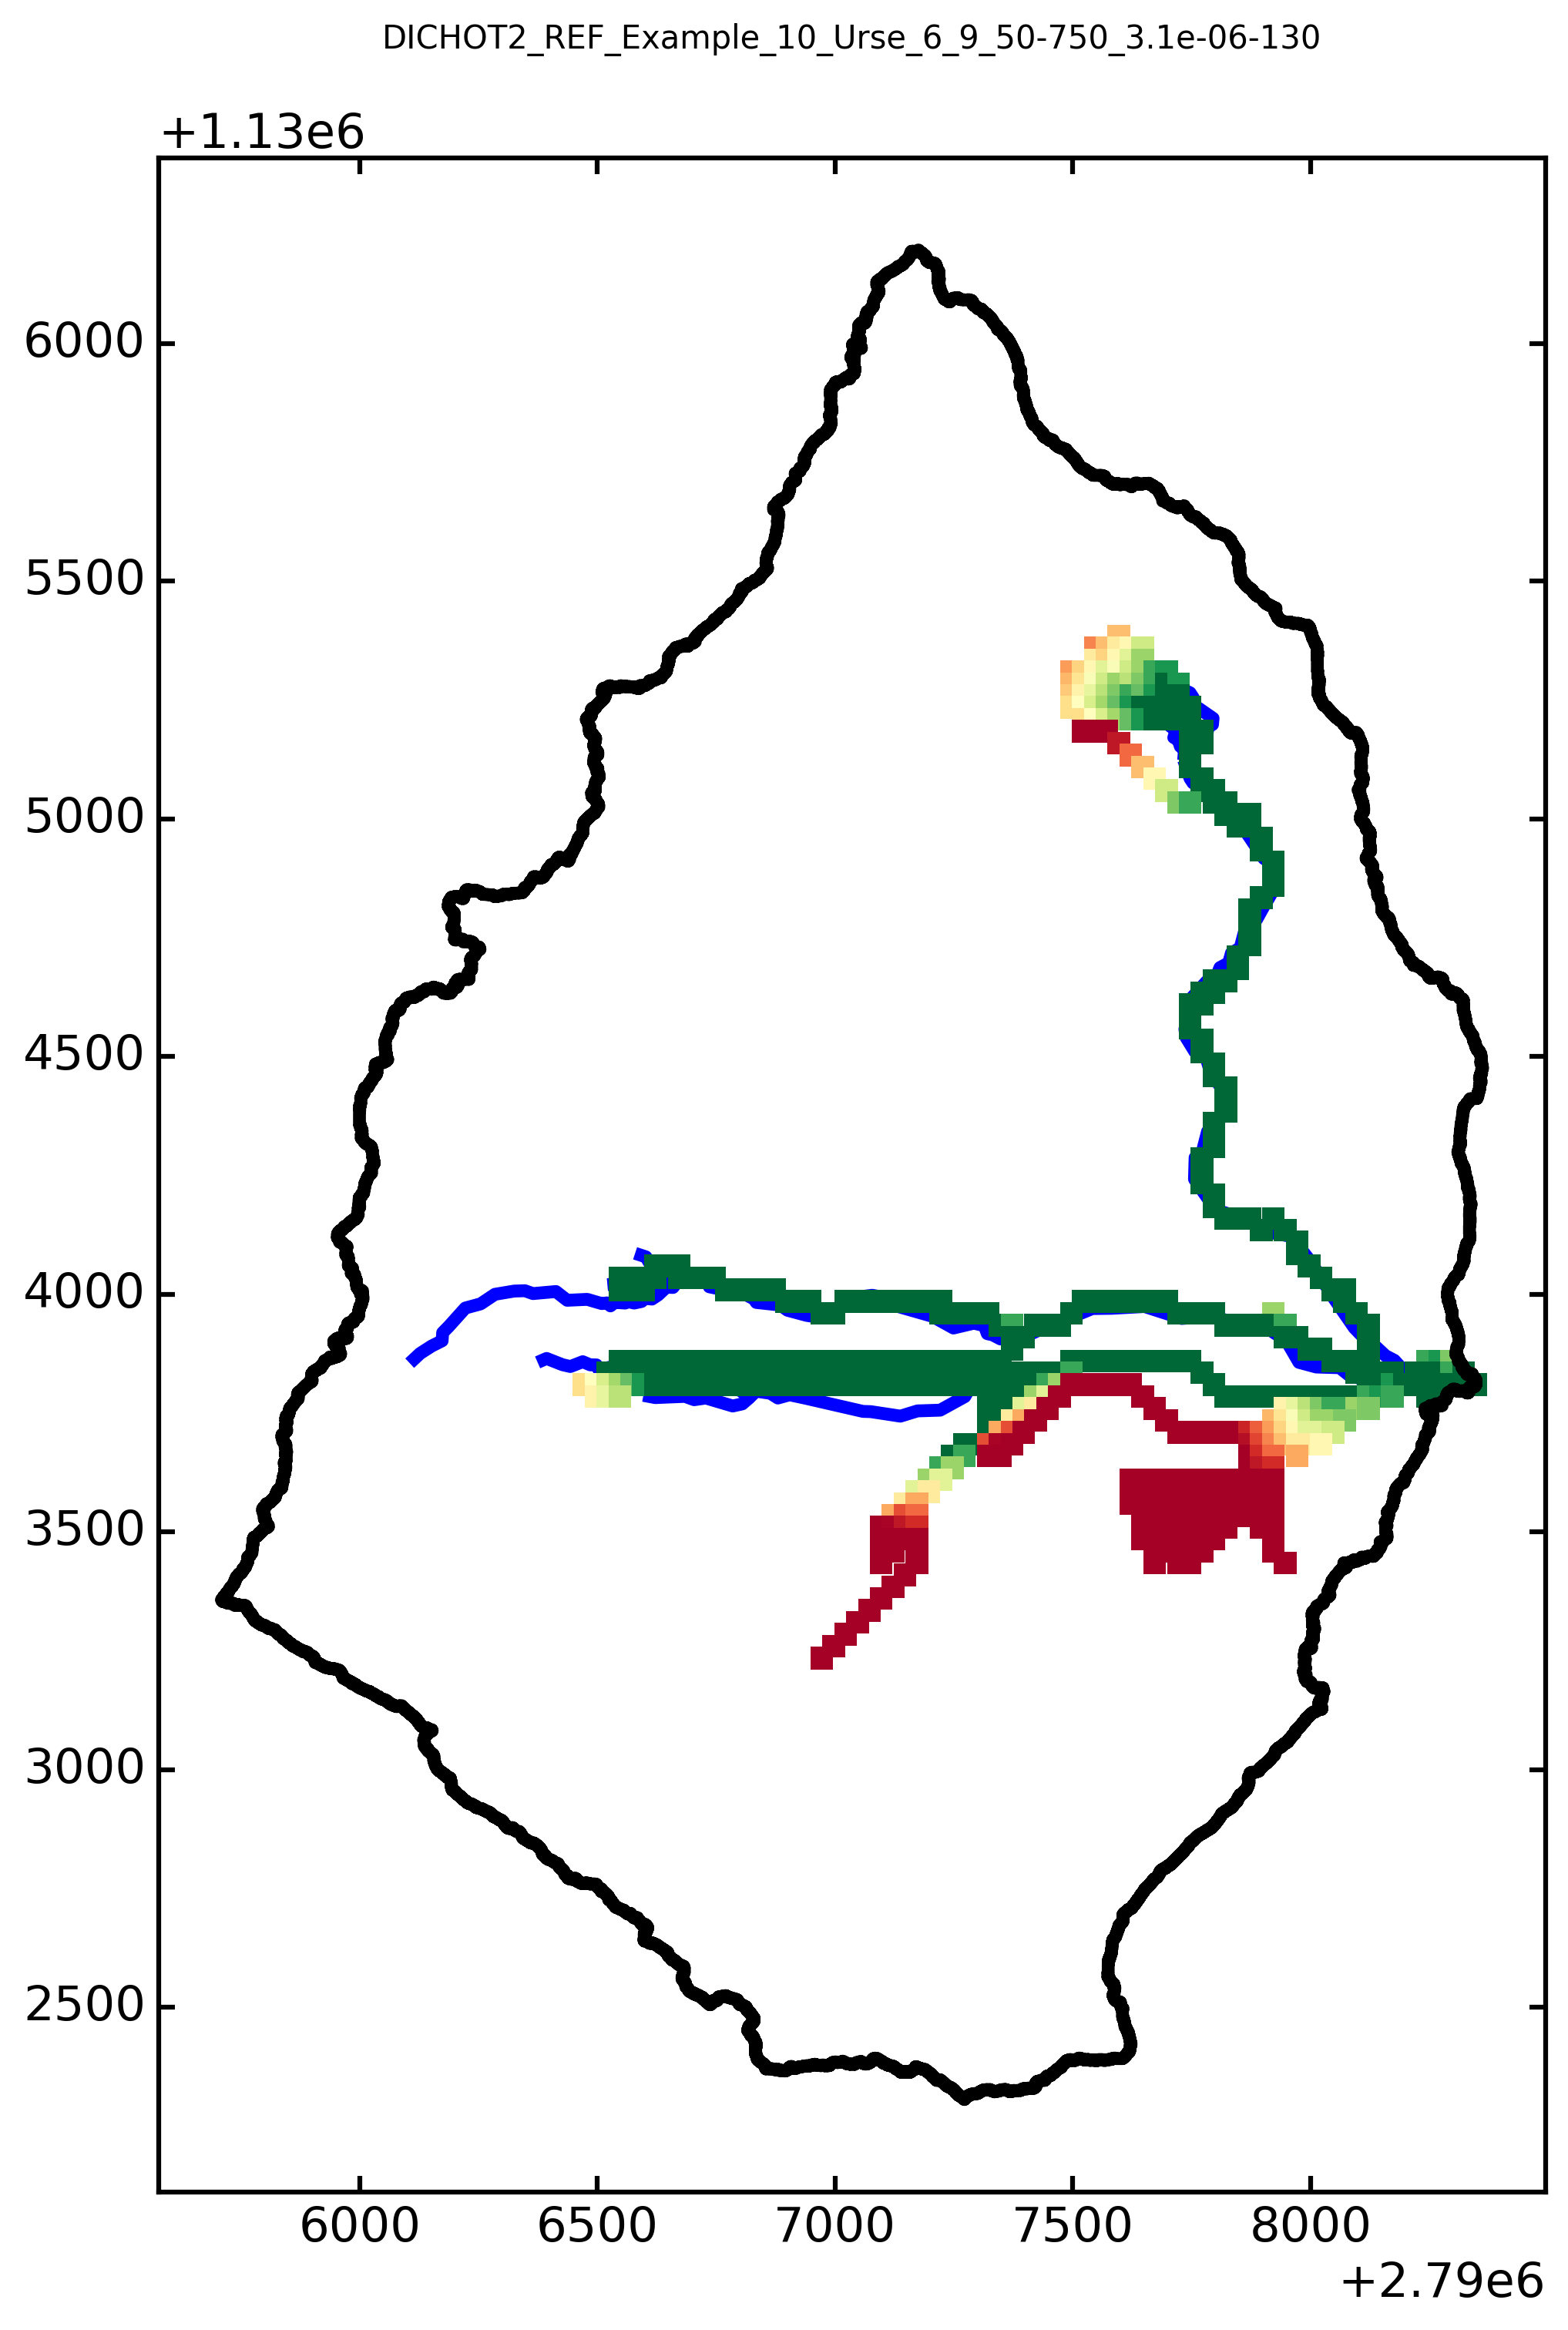

In [ ]:

BV = watershed_root.Watershed(watershed_name=watershed_name, dem_path=None, out_path=out_path, load=True)
area = BV.geographic.area

stable_folder = os.path.join(out_path, watershed_name, 'results_stable') # necessary for plots
simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')
calibration_folder = os.path.join(out_path, watershed_name, 'results_calibration')

model_names = [
    path for path in glob.glob(os.path.join(calibration_folder, vers + '*'))
    if os.path.isdir(path)
]
model_names.sort()
model_name_ref = model_names[-1]

WC0 = os.path.join(stable_folder, 'geographic', 'watershed.shp')
WC_shp = gpd.read_file(WC0)

HYD0 = os.path.join(stable_folder, 'hydrography', 'stream_network_urse_reproj.shp')
HYD_shp = gpd.read_file(HYD0)

for i, model_path in enumerate([model_name_ref]):

    stable_folder = os.path.join(out_path, watershed_name, 'results_stable') # necessary for plots
    simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')
    calibration_folder = os.path.join(out_path, watershed_name, 'results_calibration')

    simflowf_path = os.path.join(model_path, '_matchingstreams', 'simflowf.shp')
    simflowf = gpd.read_file(simflowf_path)

    fig, ax = plt.subplots(1,1, figsize=(10,10), dpi=300)

    simflowf.plot(ax=ax, column='VALUE1', cmap='RdYlGn_r', lw=0, zorder=1, s=50,
                  marker='s',
                  vmin=0,vmax=25*10)

    HYD_shp.plot(ax=ax, color='blue', lw=4, zorder=0)

    WC_shp.plot(ax=ax, facecolor='None', zorder=2, lw=4)

    plt.suptitle(os.path.basename(model_path), fontsize=10, y=1)

    plt.tight_layout()



In [21]:

os.chdir(DIR)
